In [2]:
# performing imports
# python libraries
import os
import string
import re
from IPython.display import display, HTML
import warnings
import tqdm
from typing import List, Tuple, Dict

# Basic ML libraries and scikit learn libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import sklearn as skl

In [3]:
# Getting current working directory
cwd = os.getcwd()
cwd

'D:\\'

In [4]:
os.chdir('D:\\My Work\\Computer Science Courses and Projects\\EMP_Work')

In [5]:
M4 = pd.read_csv("Module 4.csv", encoding='unicode_escape')

In [6]:
M4

,ID,Campus,1-Course level outcome,2-Promote the achievement of learning outcomes,3-Syllabus lists required knowledge,4-Syllabus lists needed soft skills,5-Learner survey,6-cultural prespective statement,7-Assignment's purpose,8-Assignment's estimated time,...,26-Non deficit language (assignment context),27-Non deficit language (course outcomes and description),Learning Notes,Knowledge and skills notes,Transparency notes,Envirnment Notes,Support notes,Validation notes,Language notes,Overall Reflection
0,32,Bakersfield,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,36,Chico,3.0,3.0,3.0,3.0,1.0,3.0,2.0,1.0,...,3.0,3.0,NaN,NaN,NaN,"There is an instructor introduction on Canvas,...",There are resources listed in the syllabus for...,"A no late policy listed, but also a statemen...",Student accountability and plagiarism statemen...,The syllabus review rubric was very helpful in...
2,128,Chico,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,25,Dominguez Hills,3.0,3.0,3.0,2.0,1.0,1.0,3.0,1.0,...,2.0,2.0,I have 12-course objectives and learning outco...,I have listed the prerequisites for this class...,I do have the assignment purpose listed on the...,"Aside from my name, email, ad office hours, I ...",The syllabus describes the structure of office...,I never thought about getting student testimon...,My syllabus is gender neutral. I think there a...,NaN
4,91,Dominguez Hills,3.0,3.0,2.0,2.0,1.0,3.0,3.0,2.0,...,3.0,3.0,NaN,"Although counseling requires soft skills, we d...",I provide examples for some assignments on Can...,Our department created a template syllabus to ...,I can add more information about office hours ...,This might be an area of growth and I want to ...,NaN,NaN
5,186,Dominguez Hills,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
6,11,East Bay,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
7,81,East Bay,3.0,2.0,1.0,1.0,1.0,1.0,1.0,1.0,...,3.0,3.0,"More detail on the learning activities, they a...",I have none of this. I need to do way more in ...,"Missing purpose, time and summative assessment...",What IS on the syllabus is structure and organ...,This is all there.,It never occurred to me to include points 21. ...,NaN,NaN
8,201,East Bay,3.0,3.0,3.0,1.0,1.0,3.0,1.0,1.0,...,3.0,3.0,My course is designed to connect learning to e...,My syllabus will need work in terms of soft sk...,I think I have assumed a purpose but I need to...,I tend to shy away from self disclosure and I ...,I need to include a office hour purpose in my ...,Im not big on announcing flexibility. Id pre...,NaN,NaN
9,35,Fresno,3.0,3.0,1.0,1.0,1.0,2.0,2.0,1.0,...,3.0,3.0,I teach how to write objectives aligned to sta...,I like the idea of having needed course knowle...,While the full assignment sheet is not attache...,As the syllabus is a document that is used for...,"The structure of the office hours is present, ...",I have never even considered including student...,NaN,NaN


In [7]:
M4_Numerical = M4.iloc[:,0:28]

In [8]:
M4_Numerical

,ID,Campus,1-Course level outcome,2-Promote the achievement of learning outcomes,3-Syllabus lists required knowledge,4-Syllabus lists needed soft skills,5-Learner survey,6-cultural prespective statement,7-Assignment's purpose,8-Assignment's estimated time,...,17-Office hours advantages,18-Lists campus resources (personal),19-Lists campus resources (Academic),20-Lists online resources (Acedemic),21-Student testimonials,22-Communication for flexibility,23-Race Conscious,24-Gender neutral,25-Non deficit language (resources),26-Non deficit language (assignment context)
0,32,Bakersfield,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,36,Chico,3.0,3.0,3.0,3.0,1.0,3.0,2.0,1.0,...,1.0,1.0,1.0,2.0,1.0,1.0,2.0,3.0,3.0,3.0
2,128,Chico,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,25,Dominguez Hills,3.0,3.0,3.0,2.0,1.0,1.0,3.0,1.0,...,1.0,3.0,3.0,3.0,1.0,2.0,1.0,3.0,2.0,2.0
4,91,Dominguez Hills,3.0,3.0,2.0,2.0,1.0,3.0,3.0,2.0,...,1.0,3.0,3.0,2.0,1.0,1.0,1.0,3.0,3.0,3.0
5,186,Dominguez Hills,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
6,11,East Bay,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
7,81,East Bay,3.0,2.0,1.0,1.0,1.0,1.0,1.0,1.0,...,3.0,3.0,3.0,3.0,1.0,2.0,1.0,3.0,3.0,3.0
8,201,East Bay,3.0,3.0,3.0,1.0,1.0,3.0,1.0,1.0,...,1.0,2.0,2.0,2.0,1.0,1.0,3.0,3.0,3.0,3.0
9,35,Fresno,3.0,3.0,1.0,1.0,1.0,2.0,2.0,1.0,...,2.0,3.0,3.0,3.0,1.0,3.0,2.0,3.0,3.0,3.0


In [9]:
mode = M4_Numerical["12-Professor's introduction"].mode()
M4_Numerical["12-Professor's introduction"].fillna(mode[0],inplace=True)

In [10]:
M4_Numerical.dropna(inplace = True)

In [11]:
pd.set_option('display.max_columns', None)
pd.set_option('display.width', 1000)
display(M4_Numerical)

,ID,Campus,1-Course level outcome,2-Promote the achievement of learning outcomes,3-Syllabus lists required knowledge,4-Syllabus lists needed soft skills,5-Learner survey,6-cultural prespective statement,7-Assignment's purpose,8-Assignment's estimated time,9-Assignment's example,10-Identifiable value points,11-Assignment resources given,12-Professor's introduction,13-Syllabus sparks interest,14-Course value communication,15-Well organized syllabus,16-heirarchy in typography,17-Office hours advantages,18-Lists campus resources (personal),19-Lists campus resources (Academic),20-Lists online resources (Acedemic),21-Student testimonials,22-Communication for flexibility,23-Race Conscious,24-Gender neutral,25-Non deficit language (resources),26-Non deficit language (assignment context)
1,36,Chico,3.0,3.0,3.0,3.0,1.0,3.0,2.0,1.0,1.0,3.0,2.0,1.0,3.0,3.0,3.0,3.0,1.0,1.0,1.0,2.0,1.0,1.0,2.0,3.0,3.0,3.0
3,25,Dominguez Hills,3.0,3.0,3.0,2.0,1.0,1.0,3.0,1.0,2.0,2.0,2.0,1.0,2.0,3.0,3.0,2.0,1.0,3.0,3.0,3.0,1.0,2.0,1.0,3.0,2.0,2.0
4,91,Dominguez Hills,3.0,3.0,2.0,2.0,1.0,3.0,3.0,2.0,2.0,3.0,3.0,3.0,3.0,3.0,3.0,3.0,1.0,3.0,3.0,2.0,1.0,1.0,1.0,3.0,3.0,3.0
7,81,East Bay,3.0,2.0,1.0,1.0,1.0,1.0,1.0,1.0,2.0,1.0,2.0,2.0,3.0,3.0,3.0,3.0,3.0,3.0,3.0,3.0,1.0,2.0,1.0,3.0,3.0,3.0
8,201,East Bay,3.0,3.0,3.0,1.0,1.0,3.0,1.0,1.0,2.0,3.0,2.0,1.0,3.0,3.0,2.0,1.0,1.0,2.0,2.0,2.0,1.0,1.0,3.0,3.0,3.0,3.0
9,35,Fresno,3.0,3.0,1.0,1.0,1.0,2.0,2.0,1.0,3.0,3.0,3.0,1.0,1.0,3.0,2.0,3.0,2.0,3.0,3.0,3.0,1.0,3.0,2.0,3.0,3.0,3.0
10,15,Long Beach,3.0,3.0,2.0,1.0,1.0,1.0,1.0,1.0,1.0,2.0,2.0,1.0,2.0,1.0,3.0,3.0,3.0,3.0,3.0,1.0,1.0,3.0,2.0,3.0,3.0,3.0
11,97,Long Beach,3.0,3.0,3.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,3.0,3.0,1.0,3.0,3.0,3.0,1.0,1.0,1.0,3.0,3.0,3.0
12,22,Monterey Bay,3.0,3.0,3.0,3.0,1.0,2.0,3.0,1.0,2.0,3.0,3.0,1.0,2.0,3.0,3.0,2.0,2.0,3.0,3.0,3.0,1.0,1.0,2.0,3.0,2.0,3.0
13,6,Northridge,3.0,3.0,2.0,1.0,1.0,1.0,2.0,3.0,3.0,3.0,3.0,3.0,2.0,3.0,3.0,3.0,2.0,3.0,2.0,1.0,1.0,3.0,1.0,3.0,3.0,3.0


In [12]:
M4_Numerical.isna().sum()

ID                                                0
Campus                                            0
1-Course level outcome                            0
2-Promote the achievement of learning outcomes    0
3-Syllabus lists required knowledge               0
4-Syllabus lists needed soft skills               0
5-Learner survey                                  0
6-cultural prespective statement                  0
7-Assignment's purpose                            0
8-Assignment's estimated time                     0
9-Assignment's example                            0
10-Identifiable value points                      0
11-Assignment resources given                     0
12-Professor's introduction                       0
13-Syllabus sparks interest                       0
14-Course value communication                     0
15-Well organized syllabus                        0
16-heirarchy in typography                        0
17-Office hours advantages                        0
18-Lists cam

In [13]:
# filling 1 na value with the median value of that column '12-Professor's introduction '
Mode = M4_Numerical["12-Professor's introduction"].mode()
print(Mode[0])
M4_Numerical.fillna(Mode[0],inplace = True)
M4_Numerical.isna().sum()

1.0


ID                                                0
Campus                                            0
1-Course level outcome                            0
2-Promote the achievement of learning outcomes    0
3-Syllabus lists required knowledge               0
4-Syllabus lists needed soft skills               0
5-Learner survey                                  0
6-cultural prespective statement                  0
7-Assignment's purpose                            0
8-Assignment's estimated time                     0
9-Assignment's example                            0
10-Identifiable value points                      0
11-Assignment resources given                     0
12-Professor's introduction                       0
13-Syllabus sparks interest                       0
14-Course value communication                     0
15-Well organized syllabus                        0
16-heirarchy in typography                        0
17-Office hours advantages                        0
18-Lists cam

In [14]:
M4_Numerical['12-Professor\'s introduction']

1     1.0
3     1.0
4     3.0
7     2.0
8     1.0
9     1.0
10    1.0
11    1.0
12    1.0
13    3.0
14    3.0
15    1.0
17    3.0
18    3.0
20    3.0
Name: 12-Professor's introduction, dtype: float64

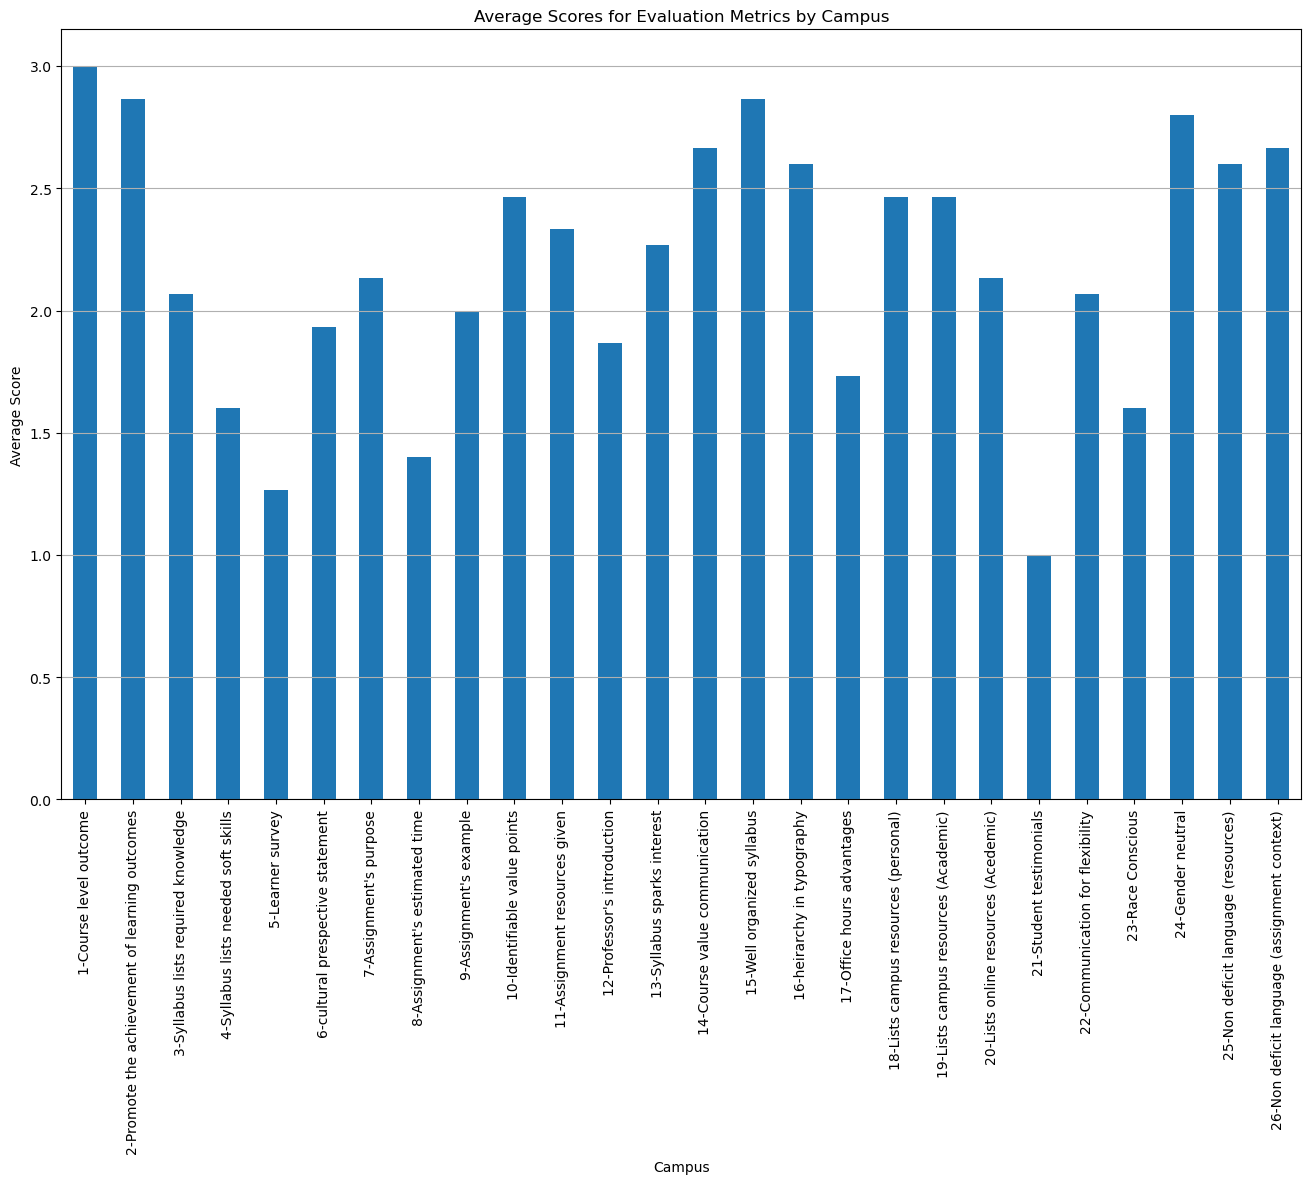

In [15]:
# Assuming M4_Numerical is your DataFrame
# Compute the average score for each metric
overall_avg_scores = M4_Numerical.iloc[:, 2:].mean()


# Plotting
plt.figure(figsize=(14, 8))
overall_avg_scores.plot(kind='bar', figsize=(16, 10), colormap='tab20')
plt.title('Average Scores for Evaluation Metrics by Campus')
plt.xlabel('Campus')
plt.ylabel('Average Score')
plt.xticks(rotation=90)
plt.grid(axis='y')

# Show the plot
plt.show()

<Figure size 2400x2000 with 0 Axes>

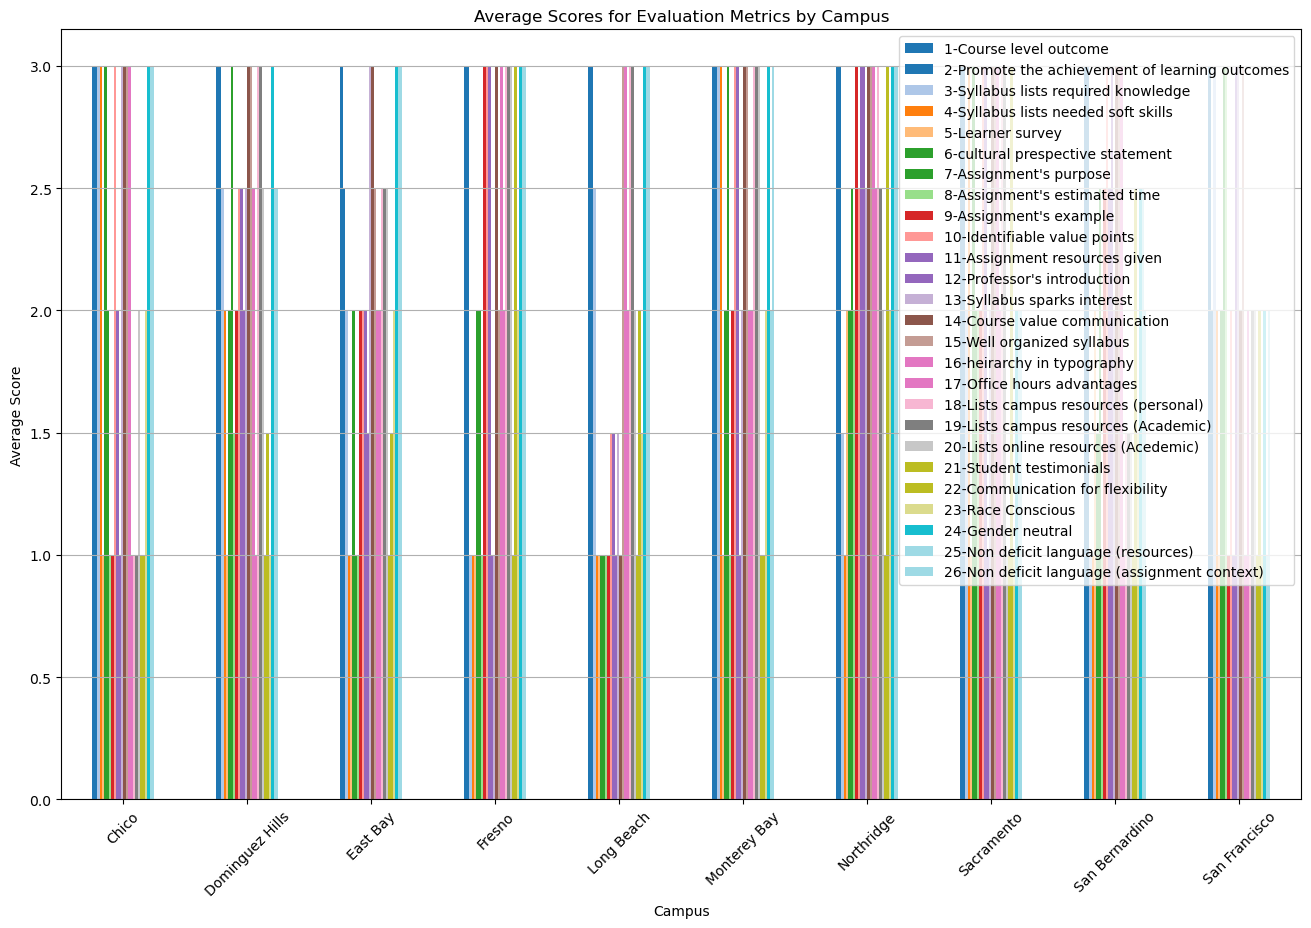

In [18]:
# Compute the average score for each metric, grouped by campus
campus_avg_scores = M4_Numerical.iloc[:,1:].groupby('Campus').mean()

# Plotting
plt.figure(figsize=(24, 20))
campus_avg_scores.plot(kind='bar', figsize=(16, 10), colormap='tab20')
plt.title('Average Scores for Evaluation Metrics by Campus')
plt.xlabel('Campus')
plt.ylabel('Average Score')
plt.xticks(rotation=45)
plt.grid(axis='y')

# Show the plot
plt.show()

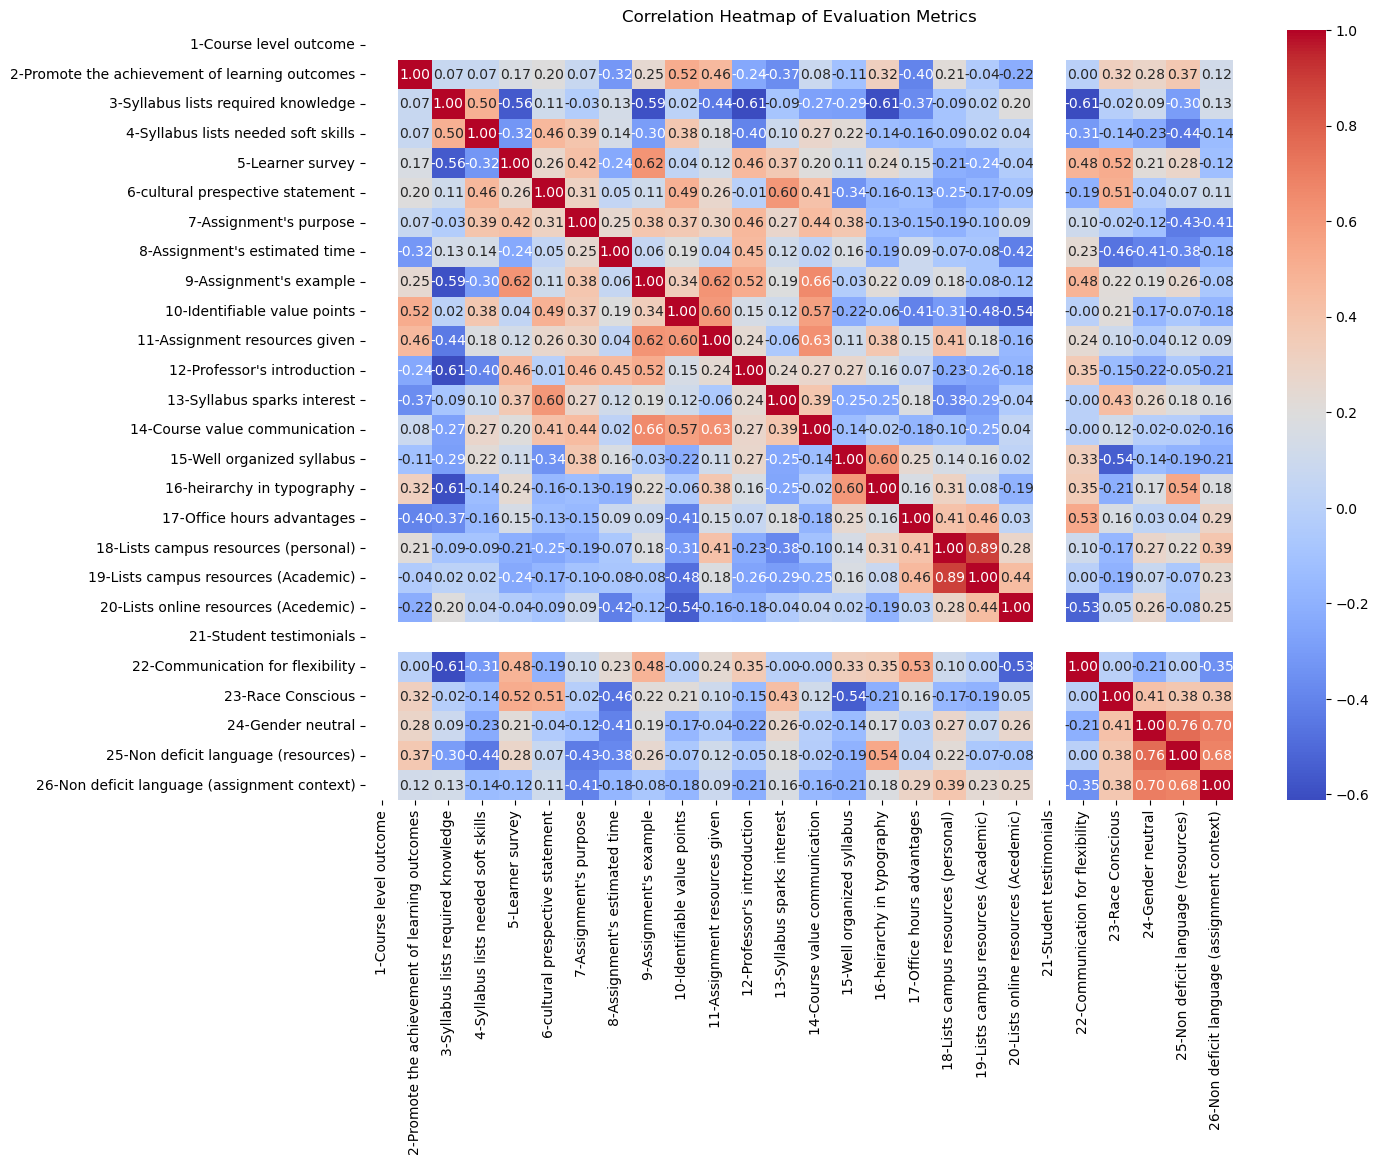

In [109]:
import seaborn as sns

# Compute the correlation matrix
correlation_matrix = M4_Numerical.iloc[:, 2:].corr()

# Plot heatmap
plt.figure(figsize=(14, 10))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Heatmap of Evaluation Metrics')
plt.show()


C:\Users\ritvi\AppData\Local\Temp\ipykernel_14256\868565369.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Metric', y='Score', data=melted_df, palette='Set2')


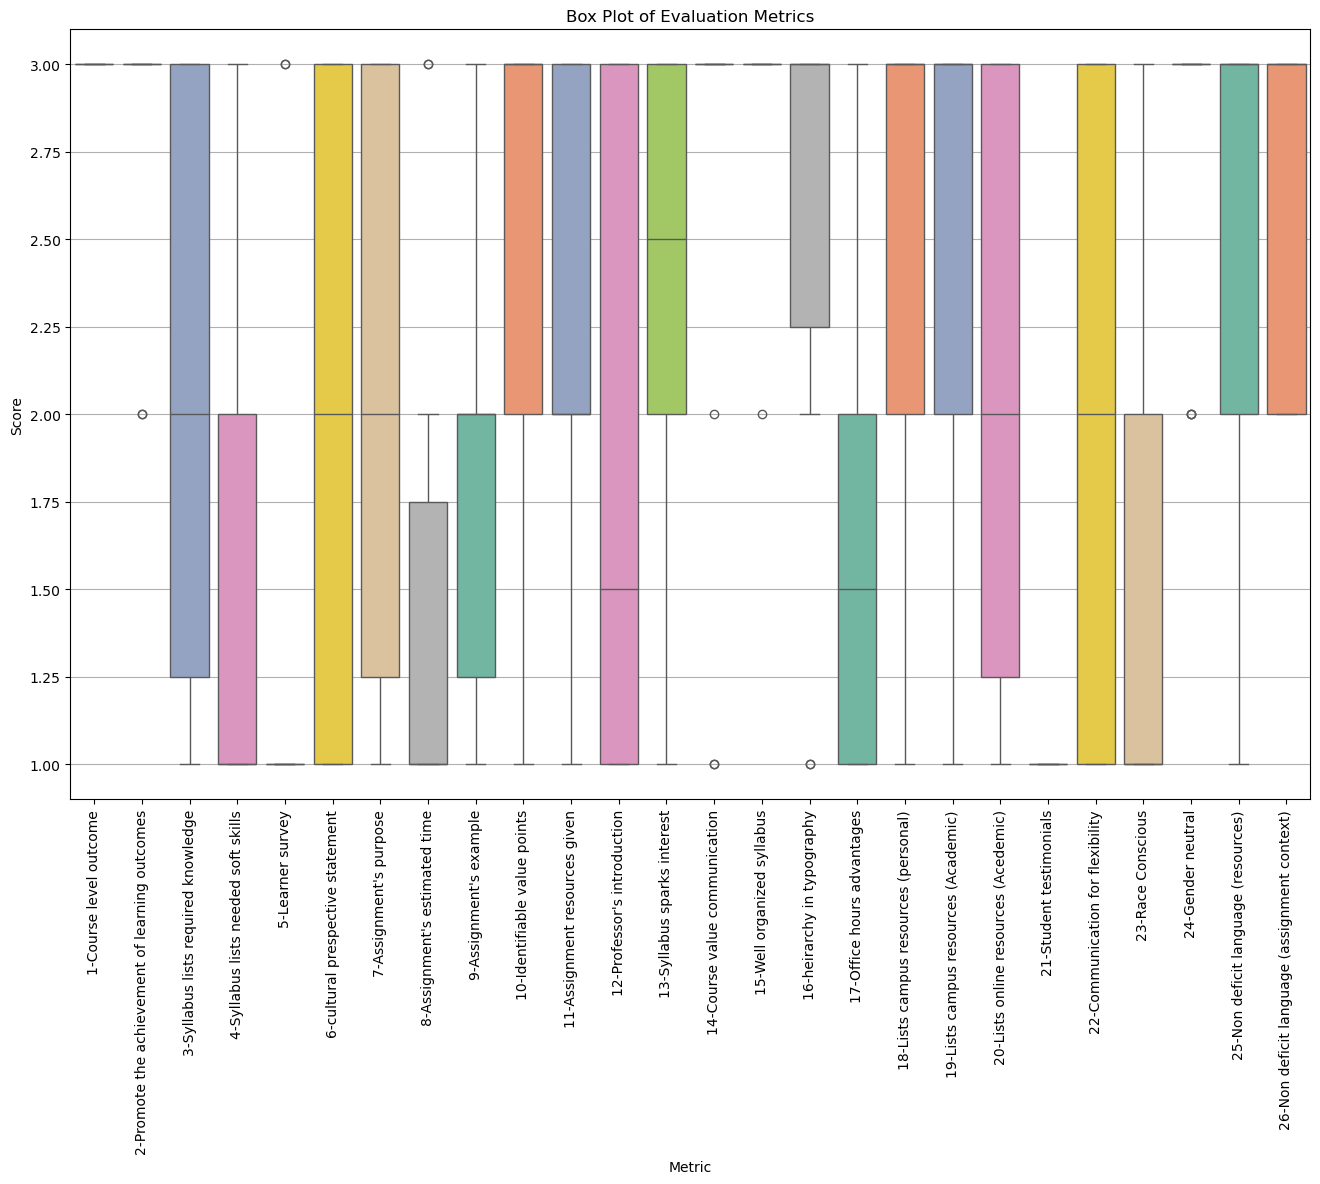

In [112]:
# Melt the DataFrame to long format
melted_df = M4_Numerical.iloc[:,1:].melt(id_vars=['Campus'], var_name='Metric', value_name='Score')

plt.figure(figsize=(16, 10))
sns.boxplot(x='Metric', y='Score', data=melted_df, palette='Set2')
plt.title('Box Plot of Evaluation Metrics')
plt.xticks(rotation=90)
plt.grid(axis='y')
plt.show()


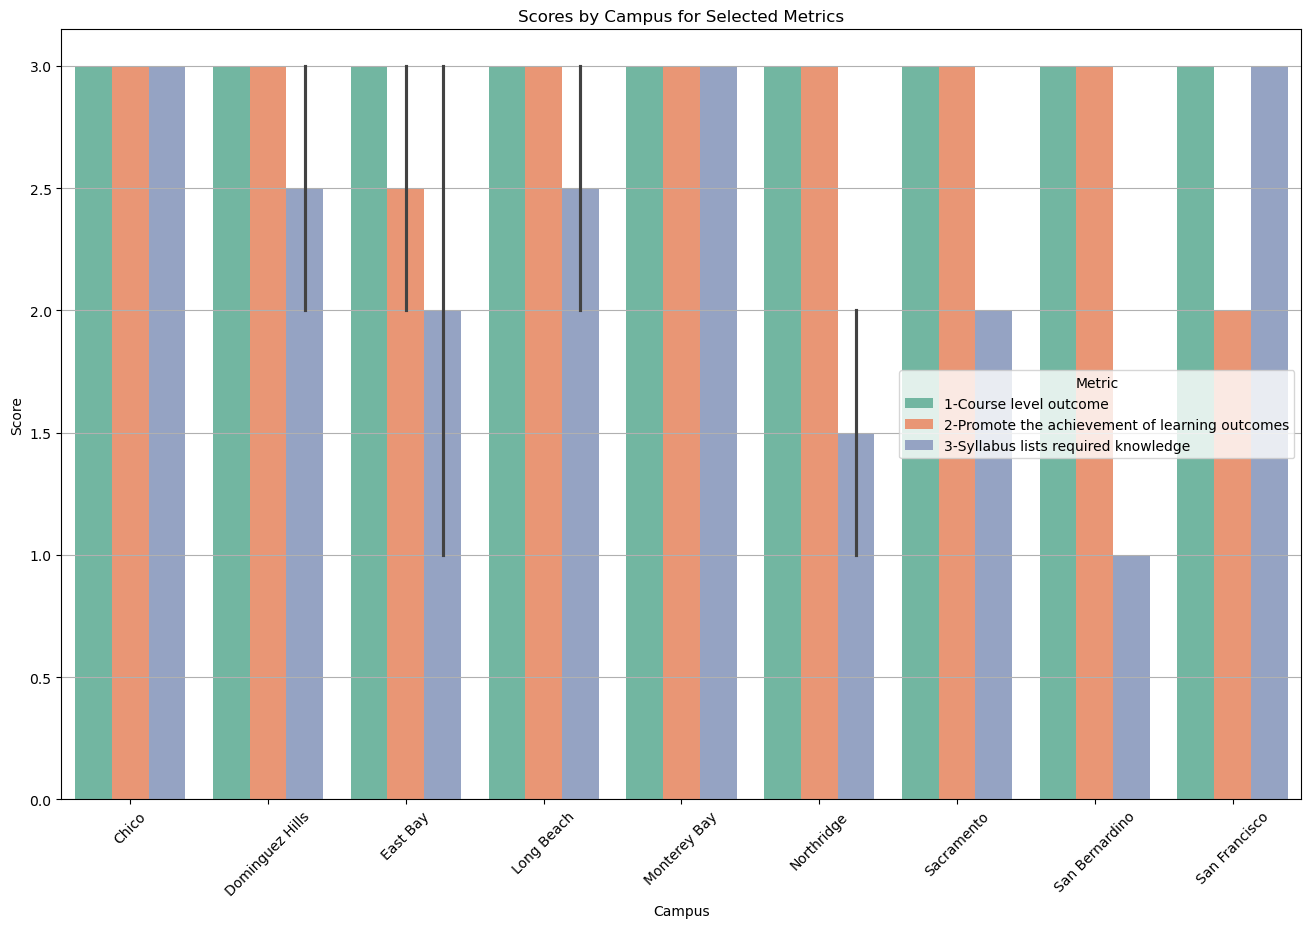

In [114]:
# selected metrics scores for all campus
selected_metrics = ['1-Course level outcome', '2-Promote the achievement of learning outcomes', '3-Syllabus lists required knowledge']

# Melt the DataFrame for selected metrics
filtered_df = M4_Numerical.melt(id_vars=['Campus'], value_vars=selected_metrics, var_name='Metric', value_name='Score')

plt.figure(figsize=(16, 10))
sns.barplot(x='Campus', y='Score', hue='Metric', data=filtered_df, palette='Set2')
plt.title('Scores by Campus for Selected Metrics')
plt.xticks(rotation=45)
plt.grid(axis='y')
plt.show()


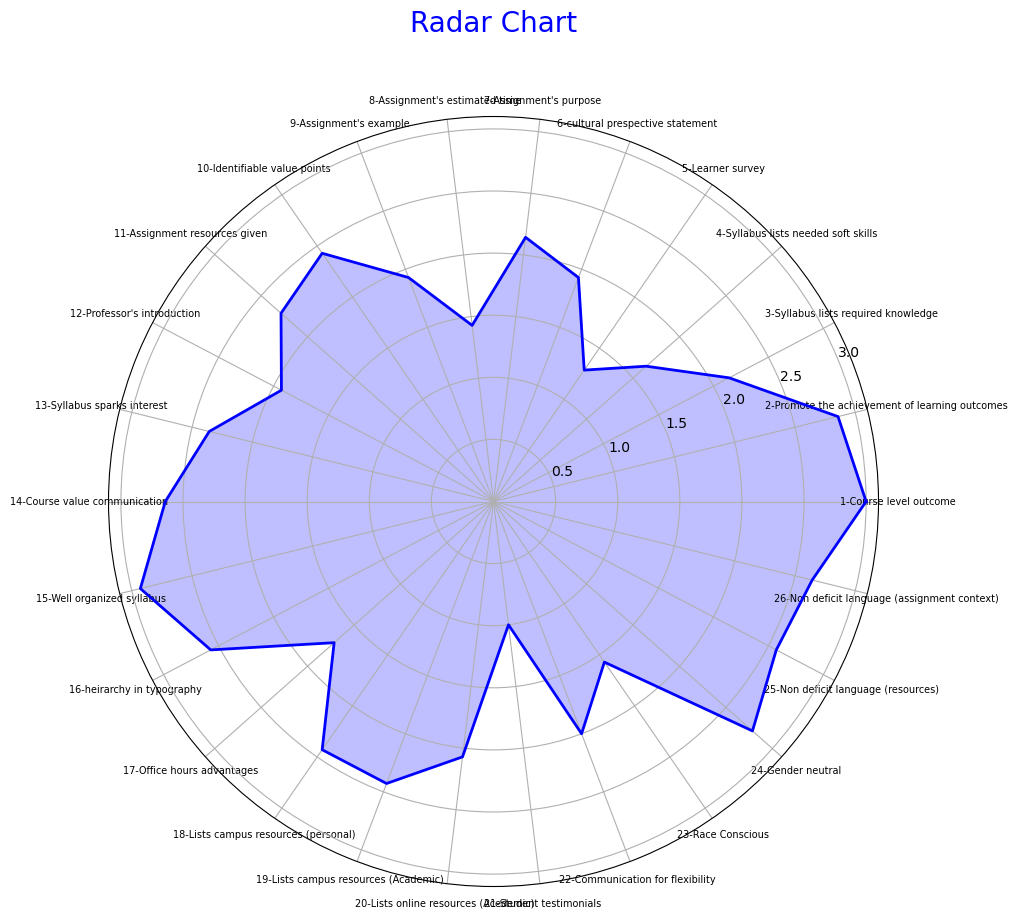

In [117]:
from math import pi

def radar_chart(data, title='Radar Chart'):
    categories = list(data.columns)
    N = len(categories)
    angles = [n / float(N) * 2 * pi for n in range(N)]
    angles += angles[:1]

    fig, ax = plt.subplots(figsize=(10, 10), subplot_kw=dict(polar=True))
    plt.xticks(angles[:-1], categories, color='black', size=7)

    # Append the first row to the end to close the radar chart
    data_row = data.iloc[0].tolist()
    data_row += data_row[:1]

    ax.plot(angles, data_row, color='blue', linewidth=2, linestyle='solid')
    ax.fill(angles, data_row, color='blue', alpha=0.25)

    plt.title(title, size=20, color='blue', y=1.1)
    plt.show()

# Prepare data for radar chart
radar_data = M4_Numerical.drop(columns=['ID', 'Campus']).mean().to_frame().T

# Plot radar chart
radar_chart(radar_data)


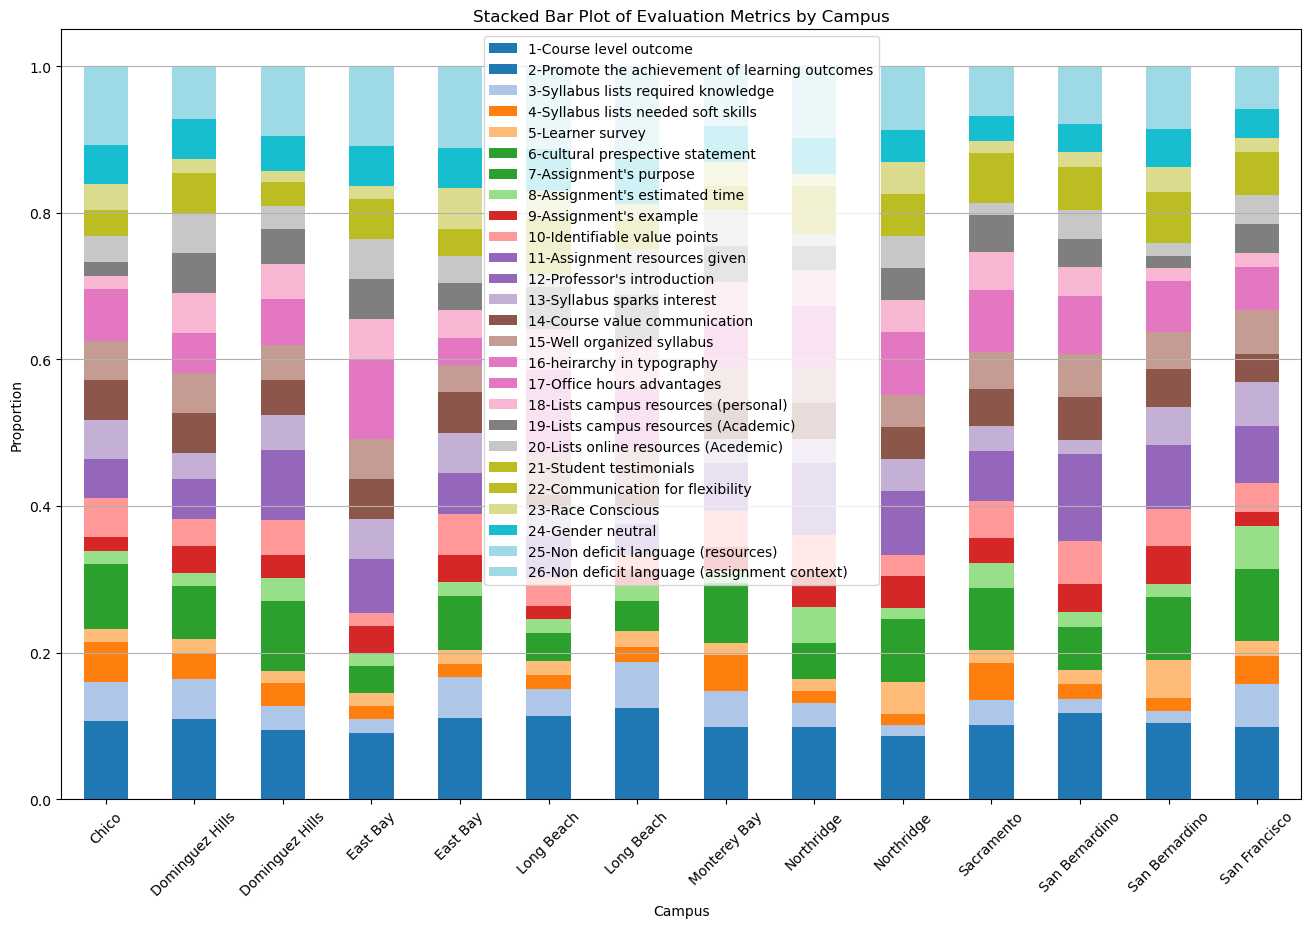

In [116]:
# Normalize the scores by campus
normalized_df = M4_Numerical.drop(columns=['ID']).set_index('Campus').div(M4_Numerical.drop(columns=['ID']).set_index('Campus').sum(axis=1), axis=0)

# Plotting
normalized_df.plot(kind='bar', stacked=True, figsize=(16, 10), colormap='tab20')
plt.title('Stacked Bar Plot of Evaluation Metrics by Campus')
plt.xlabel('Campus')
plt.ylabel('Proportion')
plt.xticks(rotation=45)
plt.grid(axis='y')
plt.show()
